In [ ]:
# Import TensorFlow as the main deep learning framework
import tensorflow as tf
# Import Keras layers to build the neural network later
from tensorflow.keras import layers
# Import Keras models to define the model structure later
from tensorflow.keras import models
# Import zipfile to extract the dataset archive
import zipfile
# Import os for file and folder path handling
import os


In [ ]:
# Open the ZIP dataset file in read mode
with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    # Extract all files into a folder named 'data'
    zip_ref.extractall('data')


In [ ]:
# STEP 1: Load the image datasets from the training and test folders
# TensorFlow automatically uses the subfolder names ('cats' and 'dogs') as class labels
training_data = tf.keras.utils.image_dataset_from_directory('/content/data/training_set/training_set')
test_data = tf.keras.utils.image_dataset_from_directory('/content/data/test_set/test_set')

# Optional check: print the class names that TensorFlow found
# print(training_data.class_names)


Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [ ]:
# STEP 2: Inspect one batch from the training dataset
# take(1) returns only the first batch so we can inspect the structure safely
for images, labels in training_data.take(1):
    # Print the shape of the image batch: (batch_size, height, width, channels)
    print(images.shape)
    # Print the shape of the label batch: one label for each image in the batch
    print(labels.shape)


(32, 256, 256, 3)
(32,)


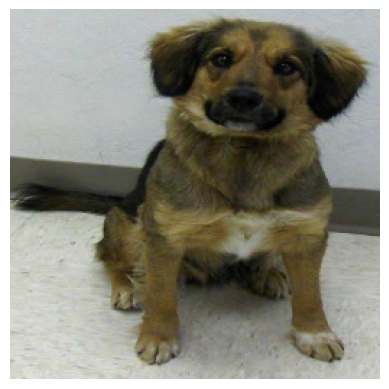

In [ ]:
# STEP 3: Visualize one image from the first training batch
# Import matplotlib to display images
import matplotlib.pyplot as plt
# Import NumPy to convert TensorFlow tensors into arrays for display
import numpy as np

for images, labels in training_data.take(1):
    # Select one image from the batch (index 13 = the 14th image)
    first_image = images[13]
    # Convert the tensor to a NumPy array and cast it to uint8 so matplotlib can render it clearly
    new_image = np.array(first_image).astype(np.uint8)
    # Display the selected image
    plt.imshow(new_image)
    # Hide axis values for a cleaner image view
    plt.axis('off')
    # Render the image in the notebook
    plt.show()


In [ ]:
# STEP 4: Create a normalization layer
# This rescales pixel values from the range 0-255 to the range 0-1
normalized_layer = tf.keras.layers.Rescaling(1./255)

# STEP 5: Apply normalization to every batch in the training dataset
# map() processes each dataset element as (images, labels)
# normalized_layer(images) scales the image pixels
# labels are returned unchanged so they still match the images
training_data = training_data.map(lambda images, labels: (normalized_layer(images), labels))

# Print the dataset object to confirm that it is now a mapped dataset
print(training_data)


<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
# STEP 6: Verify that normalization worked
# Take one batch from the normalized dataset
for images, labels in training_data.take(1):
    # Select the first image from the batch
    image = images[0]
    # Convert the tensor image to a NumPy array so we can inspect the values
    image_np = image.numpy()
    # Print the minimum pixel value in the normalized image
    print(image_np.min())
    # Print the maximum pixel value in the normalized image
    print(image_np.max())


0.01941289
0.9705742


In [ ]:
# Create a Sequential neural network model
# Sequential means layers will be added one after another in a straight pipeline
model = tf.keras.Sequential()
# Add the first convolution layer
# Conv2D scans the image to detect patterns like edges, textures, and shapes
# 32 = number of filters (pattern detectors)
# (3,3) = size of the scanning window (kernel)
# activation='relu' keeps positive signals and removes negative ones
# input_shape=(256,256,3) tells the model the size of input images (height, width, RGB channels)
model.add(tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)))
# Add a MaxPooling layer
# MaxPooling reduces the image size while keeping important features
# (2,2) means the layer looks at 2x2 blocks and keeps the largest value
# This helps reduce computation and prevents overfitting
model.add(tf.keras.layers.MaxPooling2D((2,2)))
# Add a second convolution layer
# This helps the model learn more complex patterns than the first layer
# 64 = number of filters (more pattern detectors than the first 32)
# (3,3) = filter size
# activation='relu' keeps strong positive signals and removes negative ones
model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))

# Add another max pooling layer
# This reduces the feature map size again
# It keeps the strongest features and makes the model smaller/faster
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Flatten layer converts the 3D feature maps into a 1D vector
# Dense layers cannot read image grids, they only read lists of numbers
# Flatten reshapes the data so it can go into the Dense layers
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128,activation ='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(training_data, epochs=10)
model.save("leaf_model.h5")
tf.keras.models.load_model("leaf_model.h5")
test_data=test_data.map(lambda images, labels: (normalized_layer(images), labels))

model.evaluate(test_data)


64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 887ms/step - accuracy: 0.4972 - loss: 0.6985


[0.6984290480613708, 0.4977755844593048]